# Combined difficulty vs accuracy analysis for FamilyOWL and OWL2Bench

This notebook:

- reads **all six** result files per ontology:
  - `1hop`: `nl`, `abstract`, `ttl`
  - `2hop`: `nl`, `abstract`, `ttl`
- **combines** them, so the final plots do **not** split by setting or by hop
- computes correctness for:
  - `deepseek-chat`
  - `gpt-5-mini`
  - `llama-4-maverick`
- builds **5 histograms per ontology**:
  1. ABox size
  2. Answer Type
  3. Task Type
  4. Min Tag Length
  5. Max Tag Length

## Accuracy scoring
- **BIN**: exact match with the gold `Answer`
- **MC**: overlap score  
  `(# correctly matched answers) / (# gold answers)`  
  using `;` as the separator

## Output
Plots are saved to:

- `data/output/difficulty_accuracy_analysis_combined/plots`

Tables are saved to:

- `data/output/difficulty_accuracy_analysis_combined/tables`


In [6]:

from __future__ import annotations

from collections import Counter
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120


def find_project_root(start: Path | None = None) -> Path:
    candidates: list[Path] = []
    if start is not None:
        candidates.append(Path(start).resolve())
    candidates.append(Path.cwd().resolve())

    try:
        candidates.append(Path(__file__).resolve().parent)
    except NameError:
        pass

    seen: set[Path] = set()
    for candidate in candidates:
        for place in [candidate, *candidate.parents]:
            if place in seen:
                continue
            seen.add(place)
            if (place / "pom.xml").exists() and (place / "data").exists():
                return place

    raise FileNotFoundError(
        "Could not find the project root. Open the notebook from inside the CORE-LLM-Bench repo."
    )


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "data" / "output"
LLM_RESULTS_ROOT = OUTPUT_ROOT / "llm_results"

ANALYSIS_DIR = OUTPUT_ROOT / "difficulty_accuracy_analysis_combined"
PLOTS_DIR = ANALYSIS_DIR / "plots"
TABLES_DIR = ANALYSIS_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ONTOLOGY_CONFIG = {
    "FamilyOWL": {
        "folders": ["FamilyOWL_1hop", "FamilyOWL_2hop"],
        "abox_bin_width": 10,
    },
    "OWL2Bench": {
        "folders": ["OWL2Bench_1hop", "OWL2Bench_2hop"],
        "abox_bin_width": 100,
    },
}

SETTING_FILES = {
    "nl": "nl_results_FINAL.xlsx",
    "ab": "abstract_results_FINAL.xlsx",
    "ttl": "ttl_results_FINAL.xlsx",
}

MODEL_FINAL_ANSWER_COLS = {
    "deepseek-chat": "deepseek-chat_final_answer",
    "gpt-5-mini": "gpt-5-mini_final_answer",
    "llama-4-maverick": "llama-4-maverick_final_answer",
}

MODEL_SCORE_COLS = {model: f"{model}_score" for model in MODEL_FINAL_ANSWER_COLS}

PARAMETERS = {
    "abox_size": {
        "source_col": "Size of ontology ABox",
        "title_label": "ABox size",
    },
    "answer_type": {
        "source_col": "Answer Type",
        "title_label": "Answer Type",
    },
    "task_type": {
        "source_col": "Task Type",
        "title_label": "Task Type",
    },
    "min_tag_length": {
        "source_col": "Min Tag Length",
        "title_label": "Min Tag Length",
    },
    "max_tag_length": {
        "source_col": "Max Tag Length",
        "title_label": "Max Tag Length",
    },
}

# Here, 1..6 are separate bins and 7+ is the catch-all bin.
TAG_SEPARATE_UP_TO = 6

print("PROJECT_ROOT =", PROJECT_ROOT)
print("LLM_RESULTS_ROOT =", LLM_RESULTS_ROOT)
print("PLOTS_DIR =", PLOTS_DIR)
print("TABLES_DIR =", TABLES_DIR)


PROJECT_ROOT = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2
LLM_RESULTS_ROOT = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results
PLOTS_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_combined\plots
TABLES_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_combined\tables


In [7]:

def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    return text.casefold()


def split_mc_answers(value) -> list[str]:
    if pd.isna(value):
        return []
    parts = [normalize_text(x) for x in str(value).split(";")]
    return [p for p in parts if p]


def score_mc_answer(gold_value, pred_value) -> float:
    gold = split_mc_answers(gold_value)
    pred = split_mc_answers(pred_value)

    if not gold:
        return 0.0

    gold_counter = Counter(gold)
    pred_counter = Counter(pred)
    matched = sum((gold_counter & pred_counter).values())
    return matched / len(gold)


def score_answer(answer_type, gold_value, pred_value) -> float:
    answer_type_norm = normalize_text(answer_type)

    if answer_type_norm == "mc":
        return score_mc_answer(gold_value, pred_value)

    # BIN or any other type -> exact match
    return float(normalize_text(gold_value) == normalize_text(pred_value))


def load_result_file(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    return df


def add_model_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    required_cols = {"Answer", "Answer Type", *MODEL_FINAL_ANSWER_COLS.values()}
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in result file: {missing}")

    for model_name, pred_col in MODEL_FINAL_ANSWER_COLS.items():
        score_col = MODEL_SCORE_COLS[model_name]
        df[score_col] = df.apply(
            lambda row: score_answer(
                row["Answer Type"],
                row["Answer"],
                row[pred_col],
            ),
            axis=1,
        )

    df["overall_accuracy"] = df[list(MODEL_SCORE_COLS.values())].mean(axis=1)
    return df


def get_hop_from_folder(folder_name: str) -> str:
    folder_name_lower = folder_name.lower()
    if "1hop" in folder_name_lower:
        return "1hop"
    if "2hop" in folder_name_lower:
        return "2hop"
    return "unknown"


def find_result_file(folder_name: str, setting: str) -> Path:
    filename = SETTING_FILES[setting]
    path = LLM_RESULTS_ROOT / folder_name / filename
    if not path.exists():
        raise FileNotFoundError(f"Could not find file: {path}")
    return path


def load_combined_ontology_results(ontology_name: str) -> pd.DataFrame:
    if ontology_name not in ONTOLOGY_CONFIG:
        raise KeyError(f"Unknown ontology: {ontology_name}")

    frames: list[pd.DataFrame] = []

    for folder_name in ONTOLOGY_CONFIG[ontology_name]["folders"]:
        hop = get_hop_from_folder(folder_name)

        for setting in SETTING_FILES:
            file_path = find_result_file(folder_name, setting)
            print(f"Reading: {file_path}")

            df = load_result_file(file_path)
            df = add_model_scores(df)

            df["ontology"] = ontology_name
            df["hop"] = hop
            df["setting"] = setting
            df["source_folder"] = folder_name
            df["source_file"] = file_path.name

            frames.append(df)

    combined_df = pd.concat(frames, ignore_index=True)
    return combined_df


def abox_size_to_label(value, bin_width: int) -> str:
    if pd.isna(value):
        return "Missing"
    v = int(value)
    lo = (v // bin_width) * bin_width
    hi = lo + bin_width - 1
    return f"{lo}-{hi}"


def tag_length_to_label(value) -> str:
    if pd.isna(value):
        return "Missing"
    v = int(value)
    if v <= TAG_SEPARATE_UP_TO:
        return str(v)
    return f"{TAG_SEPARATE_UP_TO + 1}+"


def add_parameter_bin(df: pd.DataFrame, parameter_key: str, ontology_name: str) -> pd.DataFrame:
    df = df.copy()
    source_col = PARAMETERS[parameter_key]["source_col"]

    if parameter_key == "abox_size":
        bin_width = int(ONTOLOGY_CONFIG[ontology_name]["abox_bin_width"])
        df["parameter_bin"] = df[source_col].apply(lambda x: abox_size_to_label(x, bin_width))

    elif parameter_key == "answer_type":
        df["parameter_bin"] = df[source_col].fillna("Missing").astype(str)

    elif parameter_key == "task_type":
        df["parameter_bin"] = df[source_col].fillna("Missing").astype(str)

    elif parameter_key in {"min_tag_length", "max_tag_length"}:
        df["parameter_bin"] = df[source_col].apply(tag_length_to_label)

    else:
        raise KeyError(f"Unknown parameter key: {parameter_key}")

    return df


def get_bin_order(df: pd.DataFrame, parameter_key: str, ontology_name: str) -> list[str]:
    bins = df["parameter_bin"].dropna().astype(str).unique().tolist()

    if parameter_key == "abox_size":
        def abox_sort_key(label: str):
            if label == "Missing":
                return (10**9, label)
            lo = int(label.split("-")[0])
            return (lo, label)
        return sorted(bins, key=abox_sort_key)

    if parameter_key == "answer_type":
        preferred = ["BIN", "MC", "Missing"]
        return [x for x in preferred if x in bins] + [x for x in bins if x not in preferred]

    if parameter_key == "task_type":
        preferred = ["Property Assertion", "Membership", "Missing"]
        return [x for x in preferred if x in bins] + [x for x in bins if x not in preferred]

    if parameter_key in {"min_tag_length", "max_tag_length"}:
        def tag_sort_key(label: str):
            if label == "Missing":
                return (10**9, label)
            if label.endswith("+"):
                return (int(label[:-1]), label)
            return (int(label), label)
        return sorted(bins, key=tag_sort_key)

    return sorted(bins)


def build_accuracy_table(df: pd.DataFrame, parameter_key: str, ontology_name: str) -> pd.DataFrame:
    work_df = add_parameter_bin(df, parameter_key, ontology_name)

    agg_dict = {score_col: "mean" for score_col in MODEL_SCORE_COLS.values()}
    agg_dict["overall_accuracy"] = "mean"
    agg_dict["Task ID"] = "count"

    agg_df = (
        work_df
        .groupby("parameter_bin", dropna=False)
        .agg(agg_dict)
        .rename(columns={"Task ID": "n"})
        .reset_index()
    )

    order = get_bin_order(work_df, parameter_key, ontology_name)
    order_map = {label: idx for idx, label in enumerate(order)}
    agg_df["sort_idx"] = agg_df["parameter_bin"].map(order_map)
    agg_df = agg_df.sort_values("sort_idx").drop(columns=["sort_idx"]).reset_index(drop=True)

    return agg_df


def plot_accuracy_histogram(
    agg_df: pd.DataFrame,
    ontology_name: str,
    parameter_key: str,
    save_path: Path | None = None,
    show_plot: bool = True,
):
    title_label = PARAMETERS[parameter_key]["title_label"]

    if parameter_key == "abox_size":
        bin_width = int(ONTOLOGY_CONFIG[ontology_name]["abox_bin_width"])
        title = f"{ontology_name} — Combined over all settings and hops\nAccuracy by {title_label} (bin width = {bin_width})"
        xlabel = f"{title_label}\n(n = evaluated question instances across nl / ab / ttl and 1hop / 2hop)"
    elif parameter_key in {"min_tag_length", "max_tag_length"}:
        title = f"{ontology_name} — Combined over all settings and hops\nAccuracy by {title_label} (bins: 1-{TAG_SEPARATE_UP_TO}, {TAG_SEPARATE_UP_TO + 1}+)"
        xlabel = f"{title_label}\n(n = evaluated question instances across nl / ab / ttl and 1hop / 2hop)"
    else:
        title = f"{ontology_name} — Combined over all settings and hops\nAccuracy by {title_label}"
        xlabel = f"{title_label}\n(n = evaluated question instances across nl / ab / ttl and 1hop / 2hop)"

    x_labels = [
        f"{label}\n(n={int(n)})"
        for label, n in zip(agg_df["parameter_bin"], agg_df["n"])
    ]
    x = np.arange(len(agg_df))

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(x, agg_df["overall_accuracy"], alpha=0.35, label="overall accuracy")

    model_order = ["deepseek-chat", "gpt-5-mini", "llama-4-maverick"]
    for model_name in model_order:
        ax.scatter(
            x,
            agg_df[MODEL_SCORE_COLS[model_name]],
            s=45,
            label=model_name,
            zorder=3,
        )

    ax.set_title(title)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel(xlabel)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Model / overall")

    plt.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


def run_combined_analysis(show_plots: bool = False, save_tables: bool = True):
    all_plot_paths: list[Path] = []
    all_summary_tables: dict[str, pd.DataFrame] = {}
    combined_datasets: dict[str, pd.DataFrame] = {}

    for ontology_name in ONTOLOGY_CONFIG:
        print("\n" + "=" * 80)
        print(f"Loading combined data for {ontology_name}")
        print("=" * 80)

        combined_df = load_combined_ontology_results(ontology_name)
        combined_datasets[ontology_name] = combined_df

        combined_save_path = TABLES_DIR / f"{ontology_name}_combined_all_rows.csv"
        if save_tables:
            combined_df.to_csv(combined_save_path, index=False)

        print(f"Combined rows for {ontology_name}: {len(combined_df)}")

        for parameter_key in PARAMETERS:
            agg_df = build_accuracy_table(combined_df, parameter_key, ontology_name)

            filename = f"{ontology_name}_combined_{parameter_key}_accuracy.png"
            save_path = PLOTS_DIR / filename

            plot_accuracy_histogram(
                agg_df=agg_df,
                ontology_name=ontology_name,
                parameter_key=parameter_key,
                save_path=save_path,
                show_plot=show_plots,
            )

            if save_path.exists():
                all_plot_paths.append(save_path)

            table_name = f"{ontology_name}_combined_{parameter_key}"
            all_summary_tables[table_name] = agg_df.copy()

            if save_tables:
                agg_df.to_csv(TABLES_DIR / f"{table_name}.csv", index=False)

    return {
        "plots": all_plot_paths,
        "tables": all_summary_tables,
        "combined_datasets": combined_datasets,
    }


In [8]:

results = run_combined_analysis(show_plots=False, save_tables=True)

print("\nGenerated plot files:")
for p in results["plots"]:
    print(" -", p)

print("\nNumber of plots generated:", len(results["plots"]))



Loading combined data for FamilyOWL
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_1hop\nl_results_FINAL.xlsx
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_1hop\abstract_results_FINAL.xlsx
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_1hop\ttl_results_FINAL.xlsx
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_2hop\nl_results_FINAL.xlsx
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_2hop\abstract_results_FINAL.xlsx
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\FamilyOWL_2hop\ttl_results_FINAL.xlsx
Combined rows for FamilyOWL: 10796

Loading combined data for OWL2Bench
Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-


##########################################################################################
FamilyOWL — saved plots
##########################################################################################
FamilyOWL_combined_abox_size_accuracy.png


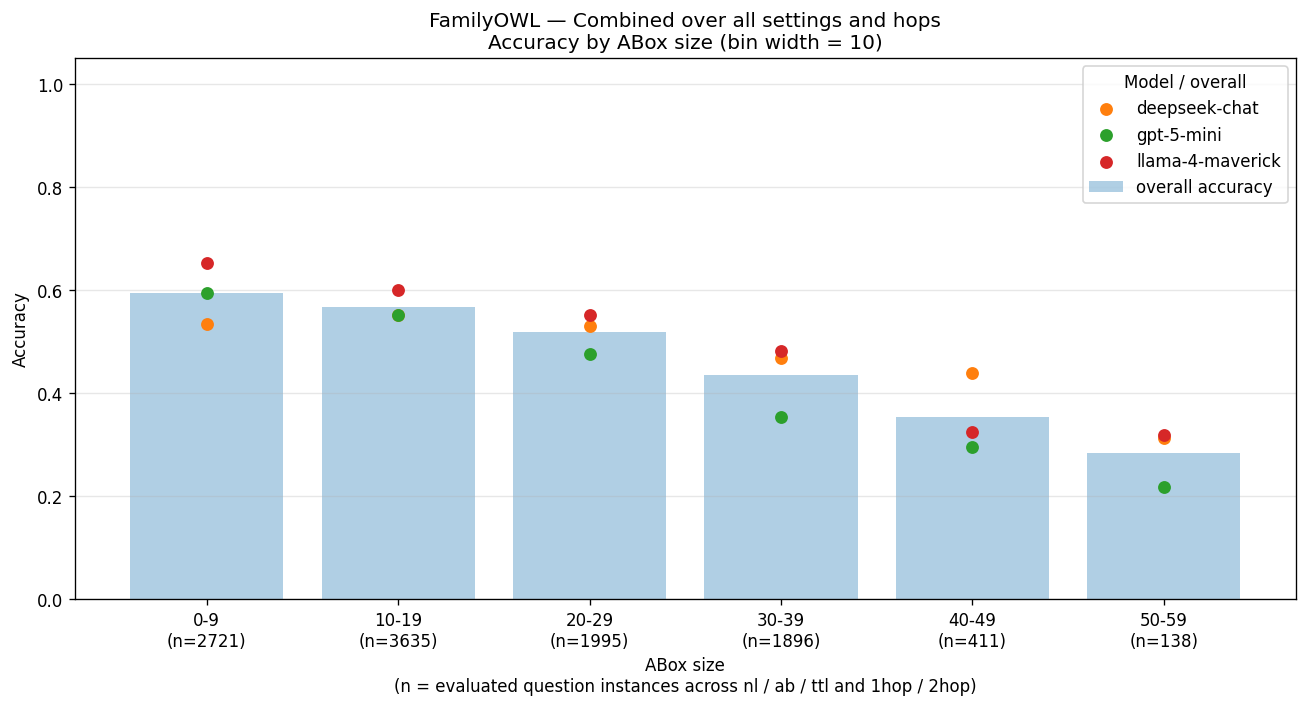

FamilyOWL_combined_answer_type_accuracy.png


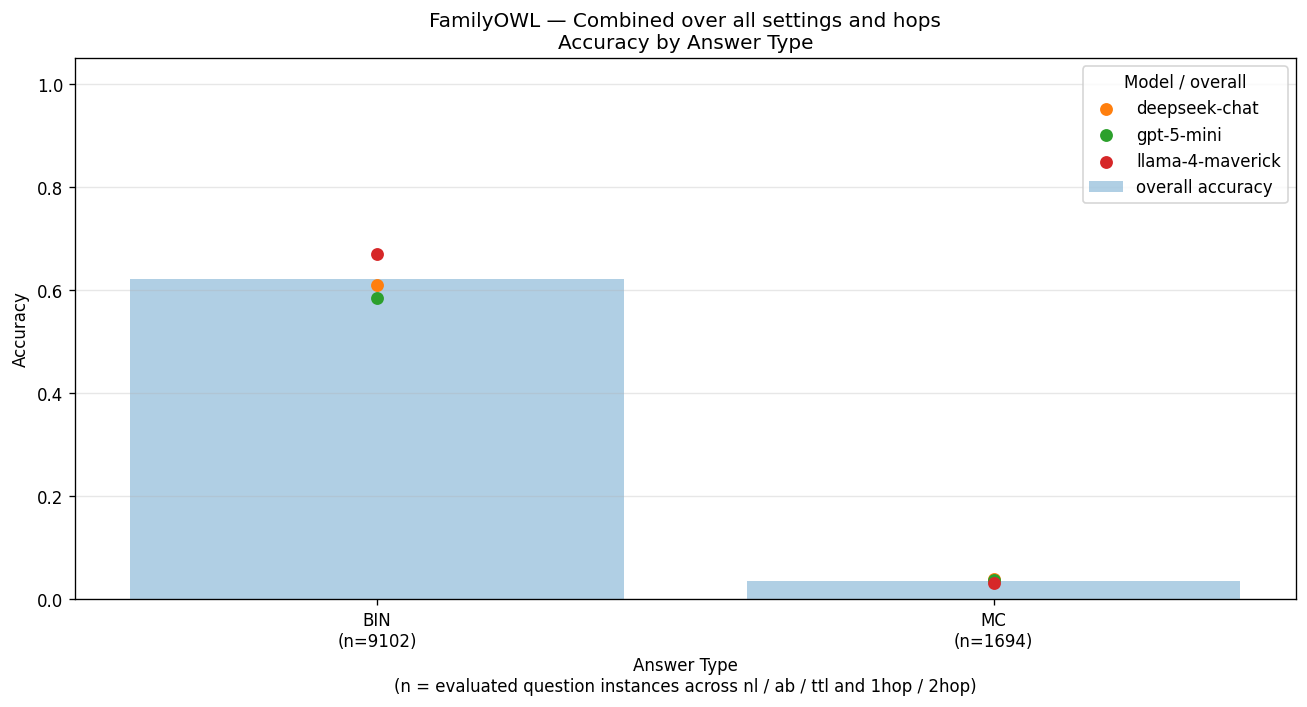

FamilyOWL_combined_max_tag_length_accuracy.png


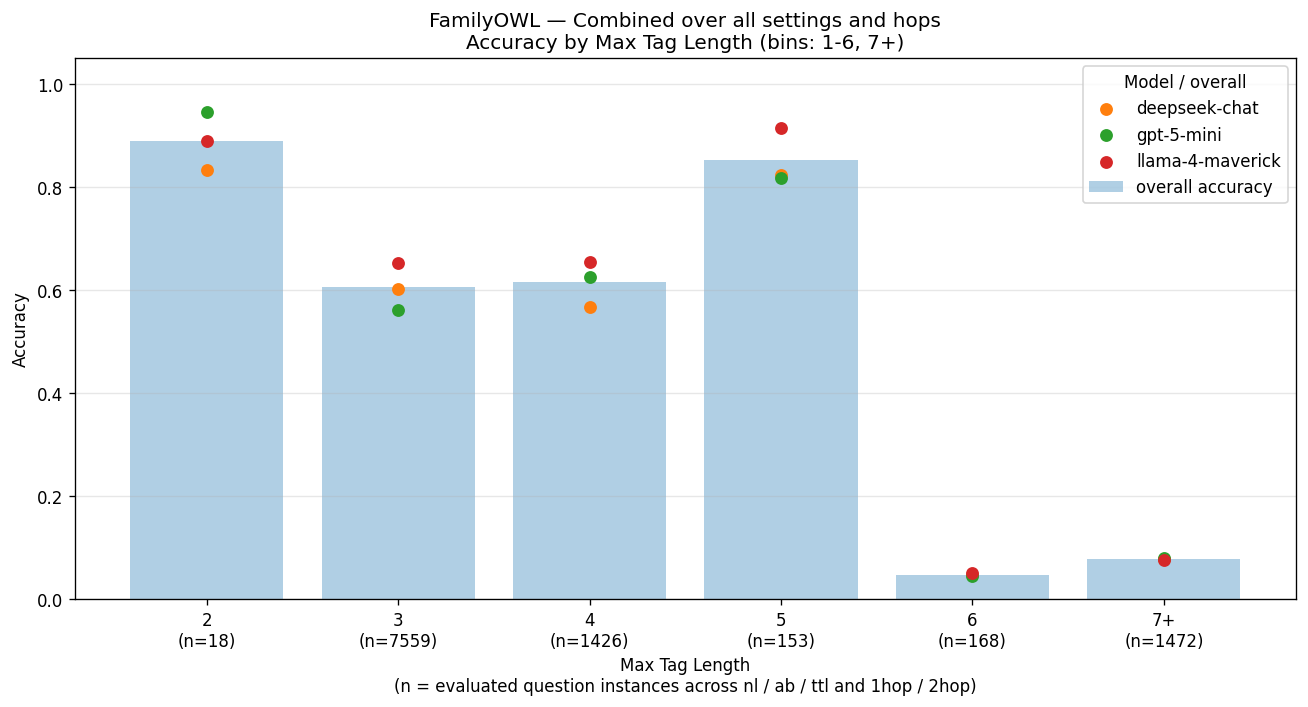

FamilyOWL_combined_min_tag_length_accuracy.png


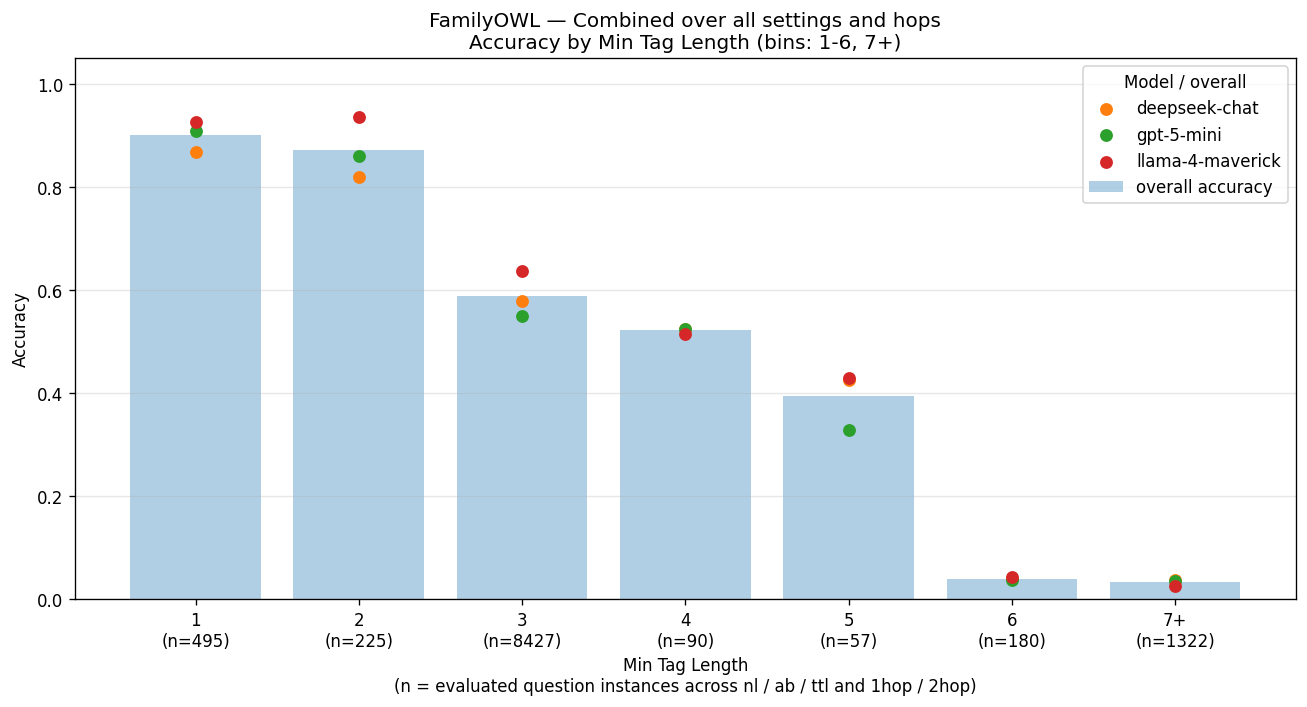

FamilyOWL_combined_task_type_accuracy.png


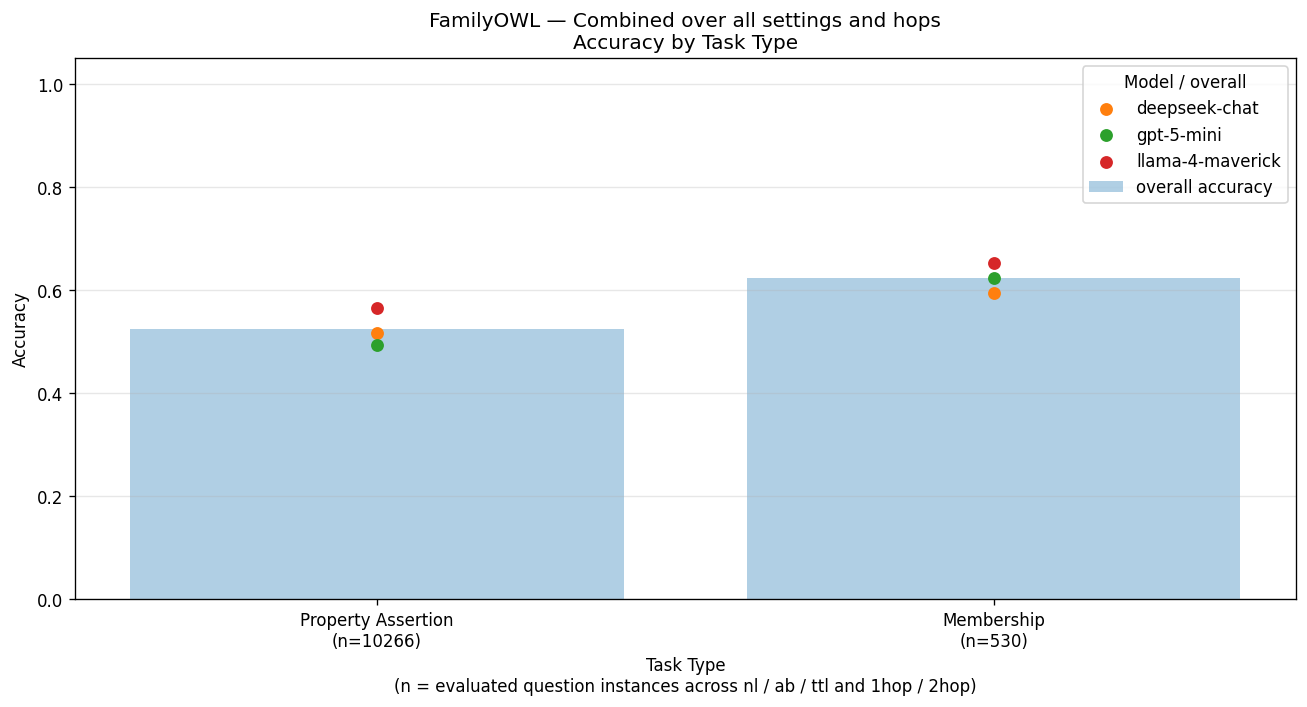


##########################################################################################
OWL2Bench — saved plots
##########################################################################################
OWL2Bench_combined_abox_size_accuracy.png


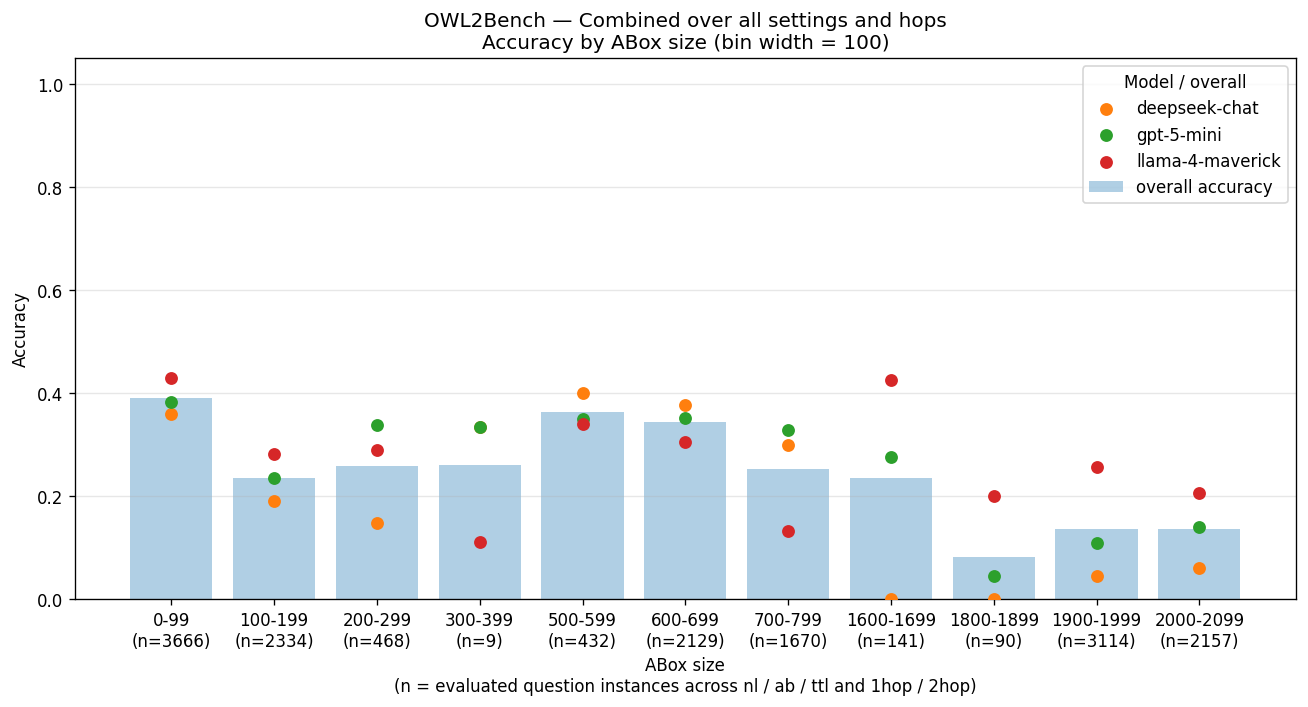

OWL2Bench_combined_answer_type_accuracy.png


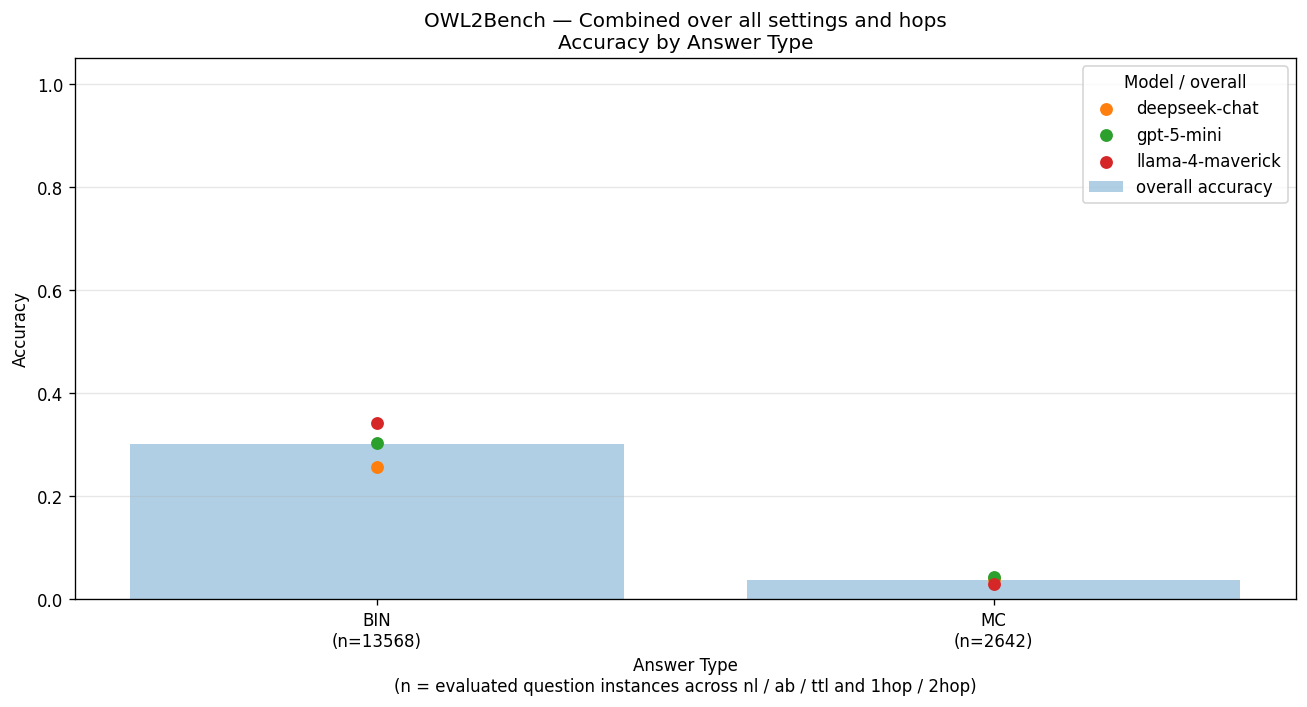

OWL2Bench_combined_max_tag_length_accuracy.png


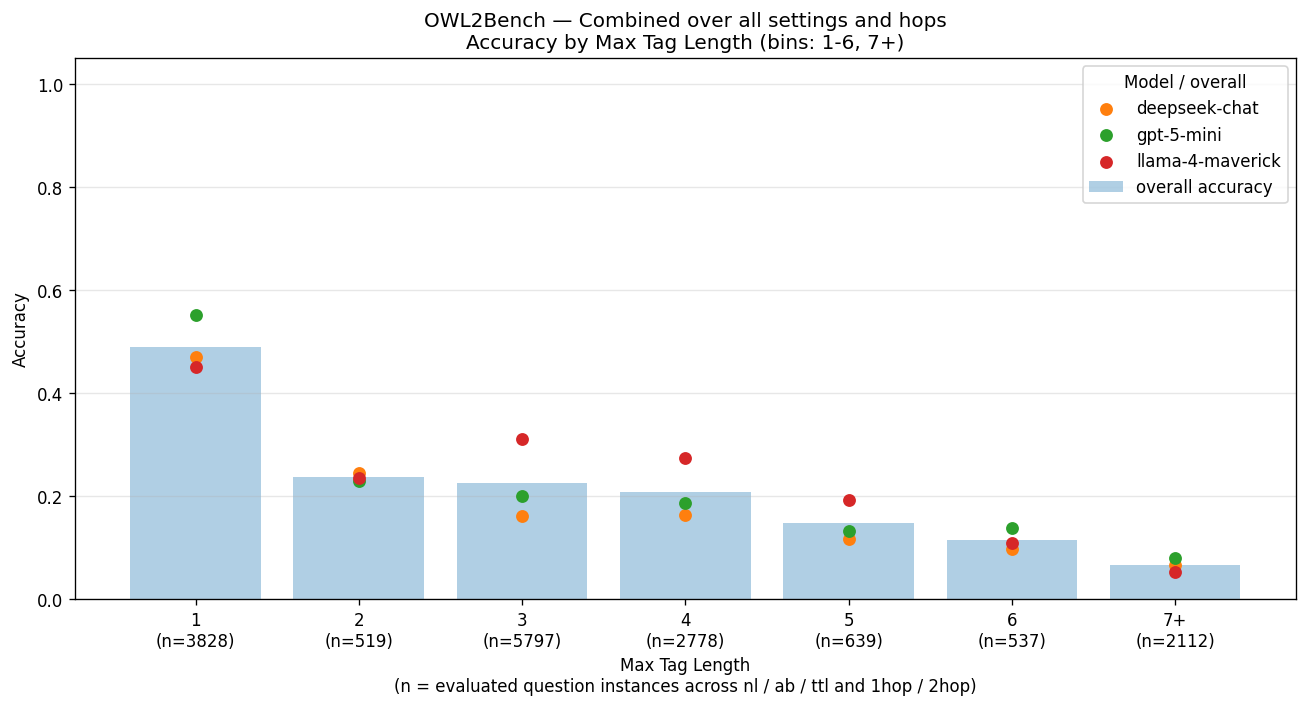

OWL2Bench_combined_min_tag_length_accuracy.png


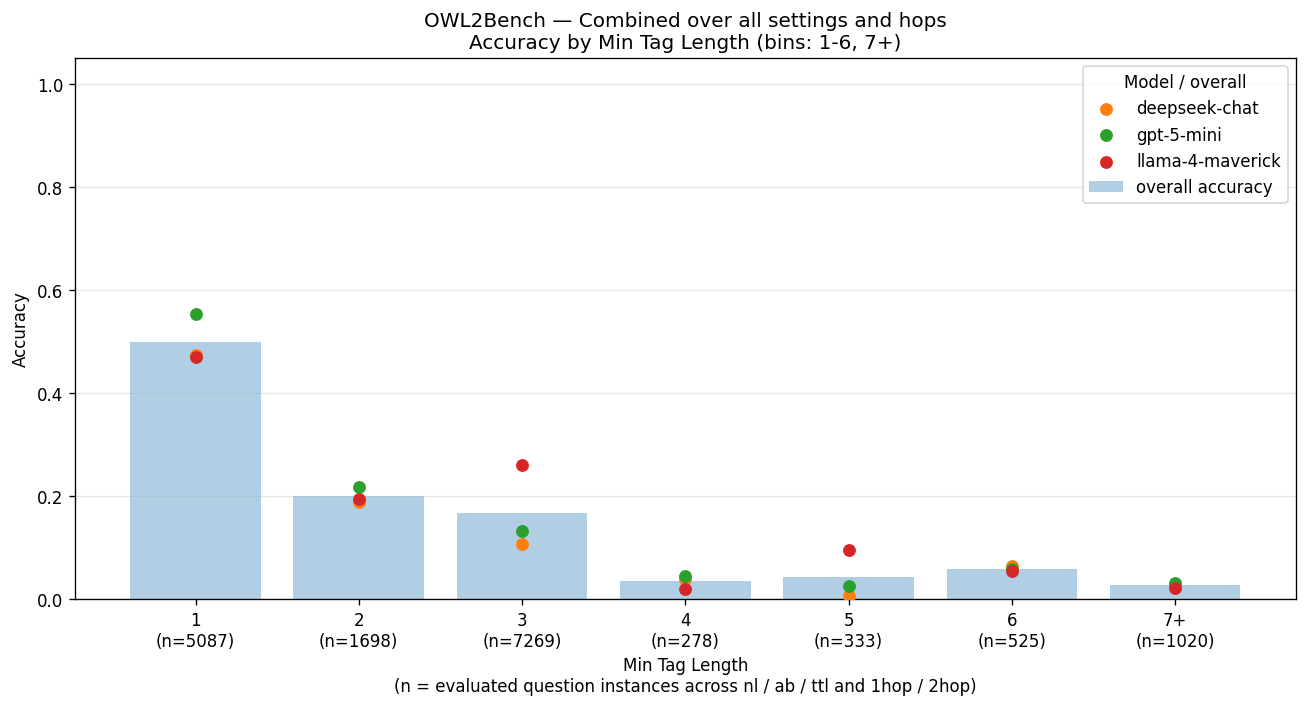

OWL2Bench_combined_task_type_accuracy.png


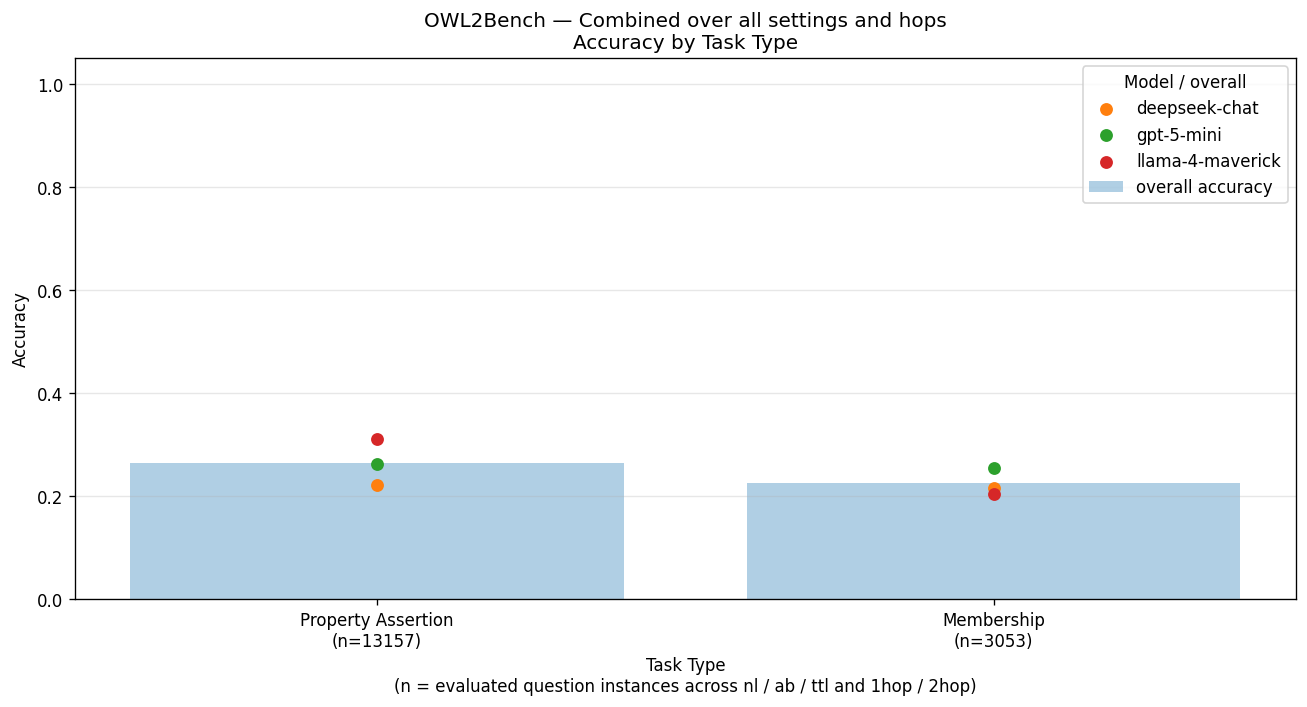

In [9]:

# Optional: preview all saved plots inside the notebook

from IPython.display import Image, display

for ontology_name in ONTOLOGY_CONFIG:
    print("\n" + "#" * 90)
    print(f"{ontology_name} — saved plots")
    print("#" * 90)

    ontology_plot_paths = sorted(PLOTS_DIR.glob(f"{ontology_name}_combined_*_accuracy.png"))
    for plot_path in ontology_plot_paths:
        print(plot_path.name)
        display(Image(filename=str(plot_path)))


In [10]:

# Optional: inspect the saved summary tables

for name, df in results["tables"].items():
    print("\n" + "=" * 90)
    print(name)
    display(df)



FamilyOWL_combined_abox_size


,parameter_bin,deepseek-chat_score,gpt-5-mini_score,llama-4-maverick_score,overall_accuracy,n
0,0-9,0.533062,0.593540,0.652421,0.593007,2721
1,10-19,0.550308,0.551858,0.598889,0.567018,3635
2,20-29,0.529162,0.474672,0.552073,0.518636,1995
3,30-39,0.467161,0.353854,0.482220,0.434412,1896
4,40-49,0.438514,0.294964,0.323865,0.352448,411
5,50-59,0.311742,0.217391,0.318841,0.282658,138



FamilyOWL_combined_answer_type


,parameter_bin,deepseek-chat_score,gpt-5-mini_score,llama-4-maverick_score,overall_accuracy,n
0,BIN,0.609866,0.585146,0.669303,0.621439,9102
1,MC,0.038073,0.037860,0.031276,0.035736,1694



FamilyOWL_combined_task_type


...

,parameter_bin,deepseek-chat_score,gpt-5-mini_score,llama-4-maverick_score,overall_accuracy,n
0,Property Assertion,0.221694,0.262582,0.310040,0.264772,13157
1,Membership,0.215755,0.254731,0.203939,0.224808,3053



OWL2Bench_combined_min_tag_length


,parameter_bin,deepseek-chat_score,gpt-5-mini_score,llama-4-maverick_score,overall_accuracy,n
0,1,0.473724,0.553414,0.470307,0.499148,5087
1,2,0.187868,0.216824,0.193708,0.199467,1698
2,3,0.106273,0.132870,0.260295,0.166479,7269
3,4,0.039568,0.044964,0.019784,0.034772,278
4,5,0.006006,0.024525,0.096096,0.042209,333
5,6,0.064127,0.058571,0.053651,0.058783,525
6,7+,0.026993,0.031228,0.022264,0.026829,1020



OWL2Bench_combined_max_tag_length


,parameter_bin,deepseek-chat_score,gpt-5-mini_score,llama-4-maverick_score,overall_accuracy,n
0,1,0.469131,0.550997,0.450266,0.490131,3828
1,2,0.244701,0.229287,0.235067,0.236352,519
2,3,0.161032,0.200592,0.311339,0.224321,5797
3,4,0.163067,0.185745,0.273248,0.207353,2778
4,5,0.117371,0.131716,0.191967,0.147018,639
5,6,0.097455,0.138734,0.108473,0.114887,537
6,7+,0.065751,0.078963,0.052735,0.065816,2112
